In [ ]:
import pandas as pd
from sklearn import svm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

In [31]:
# Load preprocessed data
data_dir = '../data/processed/'

X_train = pd.read_csv(data_dir + 'X_train.csv').to_numpy()
X_val = pd.read_csv(data_dir + 'X_val.csv').to_numpy()
X_test = pd.read_csv(data_dir + 'X_test.csv').to_numpy()

y_train = pd.read_csv(data_dir + 'y_train.csv').to_numpy().flatten()
y_val = pd.read_csv(data_dir + 'y_val.csv').to_numpy().flatten()
y_test = pd.read_csv(data_dir + 'y_test.csv').to_numpy().flatten()

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Training Y shape: {y_train.shape}")
print(f"\nClass distribution in training set:")
print(f"  Existing Customer (0): {(y_train == 0).sum()}")
print(f"  Attrited Customer (1): {(y_train == 1).sum()}")

Training set shape: (11898, 22)
Validation set shape: (1519, 22)
Test set shape: (1520, 22)
Training Y shape: (11898,)

Class distribution in training set:
  Existing Customer (0): 5949
  Attrited Customer (1): 5949


In [32]:
lambda_values = [0, 0.00001, 0.0001, 0.001, 0.1, 0.5, 1.0, 5.0, 10.0]

models = [
    {'name': 'SVM Linear Default', 'kernel': 'linear'},
    {'name': 'SVM Poly Degree 2', 'kernel': 'poly', 'degree': 2},
    {'name': 'SVM Poly Degree 3', 'kernel': 'poly', 'degree': 3},
    {'name': 'SVM RBF', 'kernel': 'rbf'}
]

results = []

for model in models:
    for lam in lambda_values:
        if lam == 0:
            C = 1e6  # High C for no regularization
        else:
            C = 1 / lam
        
        # Create SVM model
        svm_kwargs = {'C': C, 'max_iter': 1000, 'random_state': 67, 'probability': True, 'kernel': model['kernel']}
        if 'degree' in model:
            svm_kwargs['degree'] = model['degree']
        
        svm_model = svm.SVC(**svm_kwargs)
        svm_model.fit(X_train, y_train)
        
        # Predictions
        y_train_pred = svm_model.predict(X_train)
        y_val_pred = svm_model.predict(X_val)
        y_test_pred = svm_model.predict(X_test)
        
        y_train_proba = svm_model.predict_proba(X_train)[:, 1]
        y_val_proba = svm_model.predict_proba(X_val)[:, 1]
        y_test_proba = svm_model.predict_proba(X_test)[:, 1]
        
        # Metrics for each dataset
        for dataset, y_true, y_pred, y_proba in [('train', y_train, y_train_pred, y_train_proba),
                                                 ('val', y_val, y_val_pred, y_val_proba),
                                                 ('test', y_test, y_test_pred, y_test_proba)]:
            acc = accuracy_score(y_true, y_pred)
            prec = precision_score(y_true, y_pred)
            rec = recall_score(y_true, y_pred)
            f1 = f1_score(y_true, y_pred)
            roc = roc_auc_score(y_true, y_proba)
            
            results.append({
                'model': model['name'],
                'lambda': lam,
                'C': C,
                'dataset': dataset,
                'accuracy': acc,
                'precision': prec,
                'recall': rec,
                'f1': f1,
                'roc_auc': roc
            })

# Create DataFrame
results_df = pd.DataFrame(results)

# Display results
print("SVM Performance Results:")
print("=" * 80)
for model_name in results_df['model'].unique():
    print(f"\n{model_name}")
    print("-" * 40)
    model_df = results_df[results_df['model'] == model_name]
    for lam in lambda_values:
        print(f"\nLambda = {lam} (C = {model_df[model_df['lambda'] == lam]['C'].iloc[0]:.6f})")
        lam_df = model_df[model_df['lambda'] == lam]
        for _, row in lam_df.iterrows():
            print(f"  {row['dataset'].capitalize()} Set: Acc={row['accuracy']:.4f}, Prec={row['precision']:.4f}, Rec={row['recall']:.4f}, F1={row['f1']:.4f}, ROC-AUC={row['roc_auc']:.4f}")

SVM Performance Results:

SVM Linear Default
----------------------------------------

Lambda = 0 (C = 1000000.000000)
  Train Set: Acc=0.6852, Prec=0.6484, Rec=0.8094, F1=0.7200, ROC-AUC=0.7484
  Val Set: Acc=0.6129, Prec=0.2624, Rec=0.7787, F1=0.3926, ROC-AUC=0.7628
  Test Set: Acc=0.5908, Prec=0.2453, Rec=0.7459, F1=0.3692, ROC-AUC=0.7145

Lambda = 1e-05 (C = 100000.000000)
  Train Set: Acc=0.6852, Prec=0.6484, Rec=0.8094, F1=0.7200, ROC-AUC=0.7484
  Val Set: Acc=0.6129, Prec=0.2624, Rec=0.7787, F1=0.3926, ROC-AUC=0.7628
  Test Set: Acc=0.5908, Prec=0.2453, Rec=0.7459, F1=0.3692, ROC-AUC=0.7145

Lambda = 0.0001 (C = 10000.000000)
  Train Set: Acc=0.6852, Prec=0.6484, Rec=0.8094, F1=0.7200, ROC-AUC=0.7484
  Val Set: Acc=0.6129, Prec=0.2624, Rec=0.7787, F1=0.3926, ROC-AUC=0.7628
  Test Set: Acc=0.5908, Prec=0.2453, Rec=0.7459, F1=0.3692, ROC-AUC=0.7145

Lambda = 0.001 (C = 1000.000000)
  Train Set: Acc=0.6852, Prec=0.6484, Rec=0.8094, F1=0.7200, ROC-AUC=0.7484
  Val Set: Acc=0.6129, P

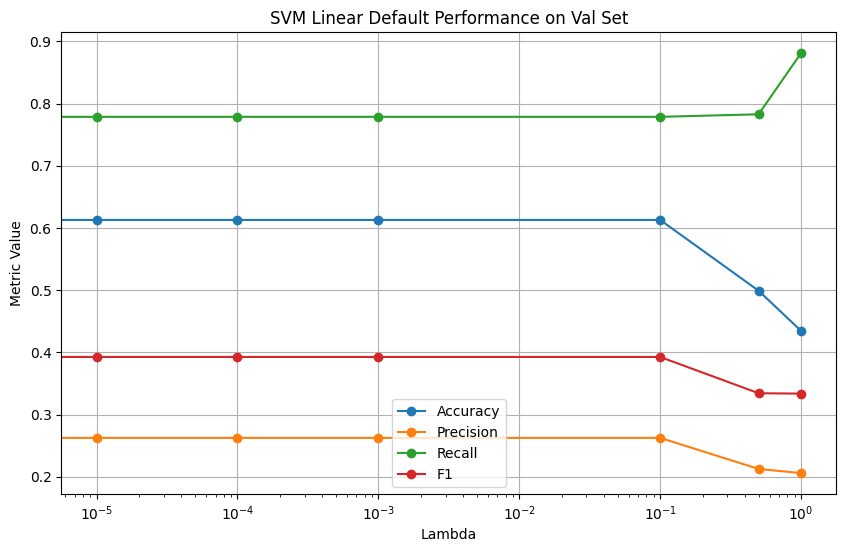

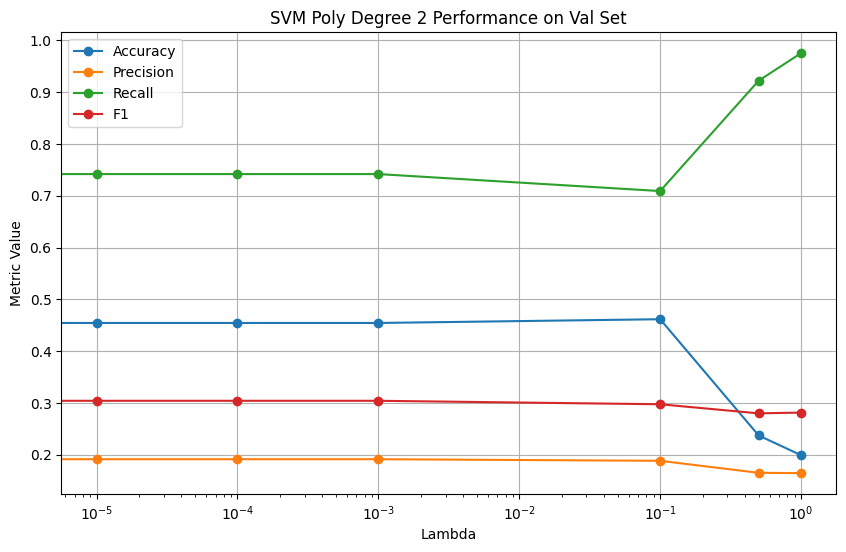

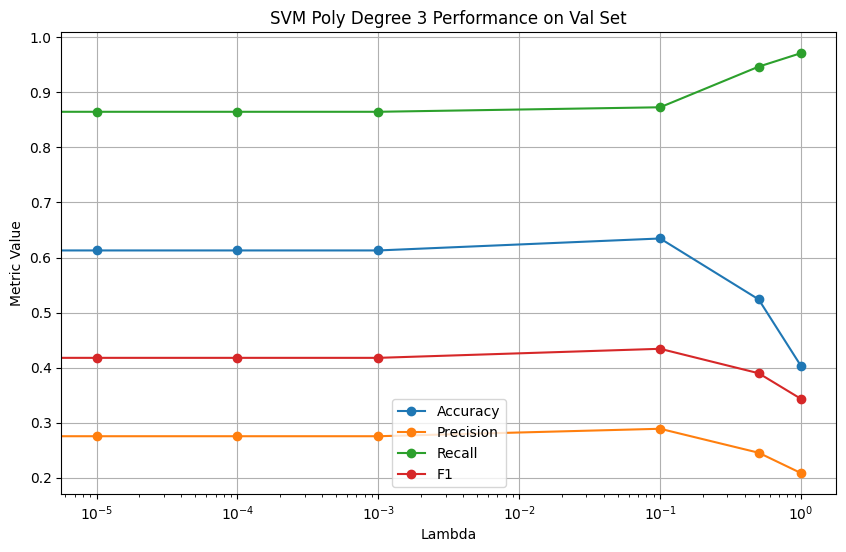

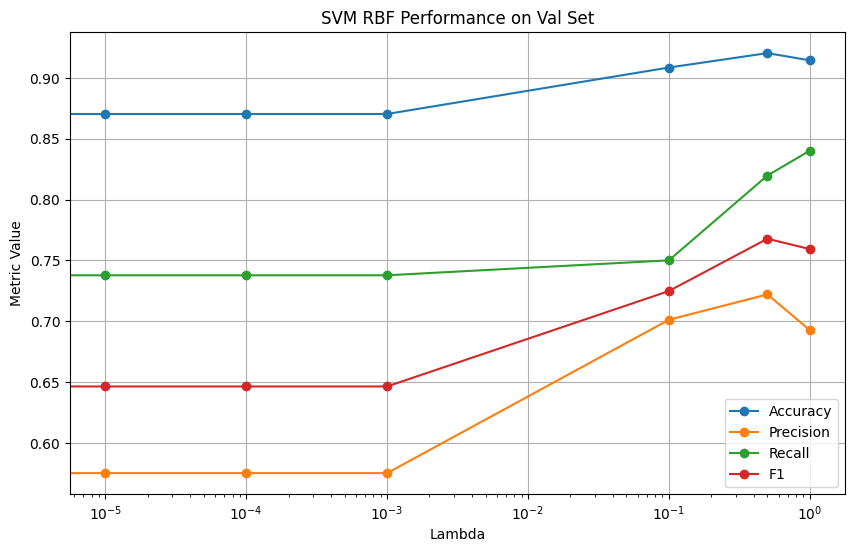

In [37]:
import matplotlib.pyplot as plt

# Filter for test set
# test_results = results_df[results_df['dataset'] == 'test']
test_results = results_df[results_df['dataset'] == 'val']

# Metrics to plot
metrics = ['accuracy', 'precision', 'recall', 'f1']

# For each model, create a plot
for model_name in test_results['model'].unique():
    model_data = test_results[test_results['model'] == model_name].sort_values('lambda')
    
    plt.figure(figsize=(10, 6))
    for metric in metrics:
        plt.plot(model_data['lambda'][:-2], model_data[metric][:-2], marker='o', label=metric.capitalize())
    
    plt.xlabel('Lambda')
    plt.ylabel('Metric Value')
    plt.title(f'{model_name} Performance on Val Set')
    plt.legend()
    plt.grid(True)
    plt.xscale('log')  # Since lambda values span orders of magnitude
    plt.show()